In [1]:
%pip install transformers torch

  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached torch-2.10.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached huggingface_hub-1.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.2.28-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.25.1-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.3.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.wh


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import os

print("Loading CLIP Zero-Shot Model... (This might take a minute the first time)")
# Load the pipeline
classifier = pipeline("zero-shot-image-classification", model="openai/clip-vit-base-patch32")
print("Model loaded and ready!")

# 1. Define your EXACT categories in plain English. 
# You can be as descriptive as you want here!
# Highly descriptive labels tailored for Indian street scenarios
# Map the long, descriptive AI labels to short, UI-friendly names
LABEL_MAPPING = {
    "a severe pothole, broken tarmac, or heavily damaged road surface": "Pothole",
    "an overflowing garbage bin, litter, or pile of trash dumped on the street": "Garbage Dump",
    "a flooded street, stagnant water, or severe road waterlogging": "Waterlogging",
    "dangerous hanging electrical wires, tangled cables, or fallen poles": "Electrical Hazard",
    "overflowing sewage, dirty water, or an open, blocked drainage system": "Open/Blocked Drain",
    "construction debris, malba, or building materials dumped on the side of the road": "Construction Debris",
    "a broken footpath, damaged pavement, or missing paving stones": "Broken Footpath",
    "stray animals like cows or dogs blocking the road or traffic": "Stray Animals",
    "a clean, normal, and well-maintained street with no visible issues": "Clean Street"
}

# We extract just the long descriptions to feed to the CLIP model
ai_descriptions = list(LABEL_MAPPING.keys())

def predict_civic_issue_smart(img_path):
    # Show the image (Notebook only)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Pass the long descriptive strings to the model
    predictions = classifier(img, candidate_labels=ai_descriptions)
    
    print("--- Under The Hood (AI Confidence) ---")
    for pred in predictions[:3]: # Just print top 3 to keep it clean
        print(f"{LABEL_MAPPING[pred['label']]}: {pred['score']:.2%}")
        
    # Get the top long-string prediction
    top_long_prediction = predictions[0]['label']
    
    # Translate it to the short UI string
    final_short_label = LABEL_MAPPING[top_long_prediction]
    
    print(f"\nFINAL OUTPUT TO FRONTEND: {final_short_label.upper()}")
    
    return final_short_label

Loading CLIP Zero-Shot Model... (This might take a minute the first time)


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 6972.87it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded and ready!


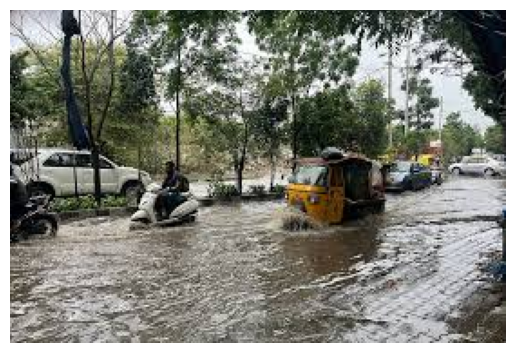

--- Under The Hood (AI Confidence) ---
Waterlogging: 93.81%
Open/Blocked Drain: 5.94%
Pothole: 0.14%

FINAL OUTPUT TO FRONTEND: WATERLOGGING


In [15]:
test_img = "water-cloged.jfif" # Make sure the name matches your file

if os.path.exists(test_img):
    predict_civic_issue_smart(test_img)
else:
    print("Image not found!")